In [ ]:
import pandas as pd
path = "Ice_cream selling data.csv"
df = pd.read_csv(path)
print(df.head())

   Temperature (°C)  Ice Cream Sales (units)
0         -4.662263                41.842986
1         -4.316559                34.661120
2         -4.213985                39.383001
3         -3.949661                37.539845
4         -3.578554                32.284531


In [2]:
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

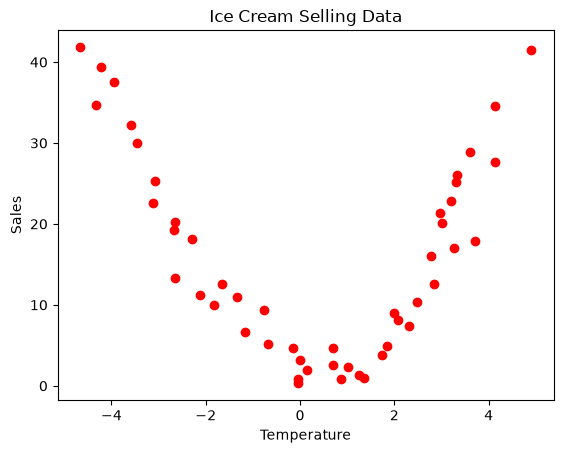

In [3]:
import matplotlib.pyplot as plt
plt.scatter(x, y, color = 'red')
plt.title('Ice Cream Selling Data')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.show()

Text(0.5, 1.0, 'Linear Regression Model')

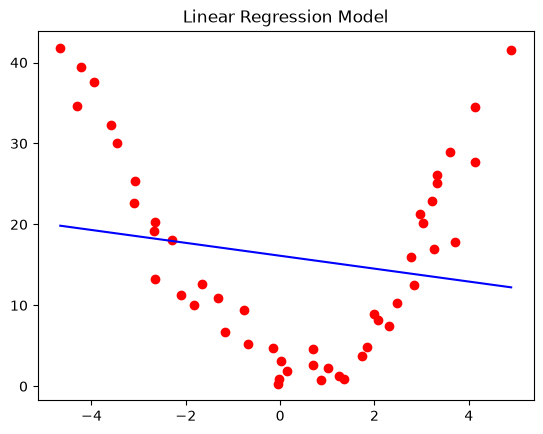

In [4]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(x, y)

plt.scatter(x, y, color = 'red')
plt.plot(x, linear_model.predict(x), color = 'blue')
plt.title('Linear Regression Model')

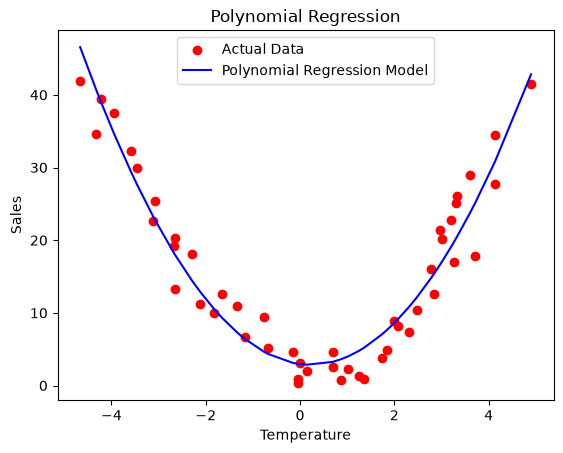

In [5]:
from sklearn.preprocessing import PolynomialFeatures

poly_reg = PolynomialFeatures(degree = 2)
x_poly = poly_reg.fit_transform(x)

linear_model2 = LinearRegression()
linear_model2.fit(x_poly, y)

y_pred_poly = linear_model2.predict(x_poly)

plt.scatter(x, y, color = 'red', label = "Actual Data")
plt.plot(x, y_pred_poly, color = 'blue', label = "Polynomial Regression Model")
plt.title('Polynomial Regression')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.legend()
plt.show()


In [7]:
print('Intercept: ', linear_model2.intercept_)
print('Coefficients: ', linear_model2.coef_)

print ('Equation: y =', linear_model2.intercept_, '+', linear_model2.coef_[1], 'x +', linear_model2.coef_[2], 'x^2')

Intercept:  2.9517741579934427
Coefficients:  [ 0.         -0.82468167  1.82952623]
Equation: y = 2.9517741579934427 + -0.824681670210649 x + 1.8295262296702088 x^2


In [8]:
dataset = pd.read_csv('manufacturing.csv')
print(dataset.head())

   Temperature (°C)  Pressure (kPa)  Temperature x Pressure  \
0        209.762701        8.050855             1688.769167   
1        243.037873       15.812068             3842.931469   
2        220.552675        7.843130             1729.823314   
3        208.976637       23.786089             4970.736918   
4        184.730960       15.797812             2918.345014   

   Material Fusion Metric  Material Transformation Metric  Quality Rating  
0            44522.217074                    9.229576e+06       99.999971  
1            63020.764997                    1.435537e+07       99.985703  
2            49125.950249                    1.072839e+07       99.999758  
3            57128.881547                    9.125702e+06       99.999975  
4            38068.201283                    6.303792e+06      100.000000  


In [9]:
x = dataset.iloc[:, 2:5].values
y = dataset.iloc[:, 5].values
x

array([[1.68876917e+03, 4.45222171e+04, 9.22957596e+06],
       [3.84293147e+03, 6.30207650e+04, 1.43553672e+07],
       [1.72982331e+03, 4.91259502e+04, 1.07283887e+07],
       ...,
       [3.95630467e+03, 6.26576910e+04, 1.40595745e+07],
       [4.97723476e+03, 5.71959855e+04, 9.13403620e+06],
       [3.97489712e+03, 4.10923929e+04, 4.35891253e+06]], shape=(3957, 3))

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)


In [12]:
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

poly_reg = PolynomialFeatures(degree = 2)
x_train_poly = poly_reg.fit_transform(x_train)
x_test_poly = poly_reg.transform(x_test)

linear_model2 = LinearRegression()
linear_model2.fit(x_train_poly, y_train)

y_pred = linear_model2.predict(x_test_poly)

In [13]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
score

0.7103025312554144

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

x = dataset.iloc[:, 2:5].values
y = dataset.iloc[:, 5].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

degrees = [1, 3, 5]
results = {}

for d in degrees:
    poly_reg = PolynomialFeatures(degree=d)
    x_train_poly = poly_reg.fit_transform(x_train)
    x_test_poly = poly_reg.transform(x_test)

    model = LinearRegression()
    model.fit(x_train_poly, y_train)

    y_pred = model.predict(x_test_poly)
    score = r2_score(y_test, y_pred)

    results[d] = score
    print(f"Degree {d} -> R2 Score: {score:.4f}")


import pandas as pd
comparison = pd.DataFrame(list(results.items()), columns=['Degree', 'R2 Score'])
print("\nPerbandingan R2 Score:")
print(comparison)

Degree 1 -> R2 Score: 0.4690
Degree 3 -> R2 Score: 0.8246
Degree 5 -> R2 Score: 0.9208

Perbandingan R2 Score:
   Degree  R2 Score
0       1  0.469026
1       3  0.824629
2       5  0.920781
